# CSCIE89 HW05 – Problem 1: Image transformations of a tiger

We download a moderate-resolution photo of a tiger and use `torchvision.transforms.Compose()` to demonstrate five transformations:

1. Flip around the **horizontal** axis (upside-down).
2. Flip around the **vertical** axis (left-right mirror).
3. **10% stretch** along one diagonal.
4. **10° rotation to the left** (counter-clockwise).
5. **15° rotation to the right** (clockwise).

## 1. Install packages and import tools

In [4]:
# %pip install torch torchvision matplotlib pillow  # Uncomment once if the packages are missing.

from pathlib import Path                                # Path builds file paths that work on any OS.
import matplotlib.pyplot as plt                         # Plotting library used to display images.
from PIL import Image                                   # Pillow opens and converts image files.
import torch                                            # PyTorch: tensors (multi-dimensional arrays).
from torchvision import transforms                      # Image transformations (flip, rotate, crop, ...).
from torchvision.datasets.utils import download_url     # Helper that downloads a file from a URL.

# Choose GPU if available; otherwise use CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)
print('PyTorch:', torch.__version__, '| Device:', device)

PyTorch: 2.5.1 | Device: cpu


## 2. Download a tiger image

We download a 1024-pixel-wide tiger photo from Wikimedia Commons (moderate resolution). The file is downloaded only once.

Image size (width x height): 960 x 530


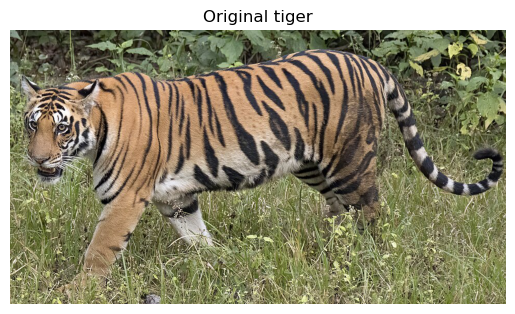

In [5]:
import urllib.request                                   # Download tool.
tiger_path = DATA_DIR / 'tiger.jpg'                     # Full path of the local image file.
tiger_url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3f/Walking_tiger_female.jpg/960px-Walking_tiger_female.jpg'  # 960-px-wide tiger photo.
if not tiger_path.exists():                             # Download only if the file is not already there.
    request = urllib.request.Request(tiger_url, headers={'User-Agent': 'Mozilla/5.0 (CSCIE89 homework)'})  # Identify ourselves; Wikimedia blocks anonymous requests.
    with urllib.request.urlopen(request) as response:   # Send the request and receive the image data.
        tiger_path.write_bytes(response.read())         # Save the downloaded bytes as tiger.jpg.
with Image.open(tiger_path) as picture:                 # Open the image file (closed automatically afterwards).
    photo = picture.convert('RGB')                      # Convert to three-channel RGB.
WIDTH, HEIGHT = photo.size                              # PIL gives the size as (width, height) in pixels.
print('Image size (width x height):', WIDTH, 'x', HEIGHT)  # Confirm the resolution.
plt.imshow(photo)                                       # Draw the original image.
plt.title('Original tiger')                             # Add a title above it.
plt.axis('off')                                         # Hide the axis ticks and labels.
plt.show()                                              # Display the figure.


## 3. Define the five transformations with `transforms.Compose()`

- **Flip around the horizontal axis:** `RandomVerticalFlip(p=1.0)` always turns the image upside-down.
- **Flip around the vertical axis:** `RandomHorizontalFlip(p=1.0)` always mirrors the image left-to-right.
- **10% stretch along one diagonal:** rotate the image 45° so the diagonal lies along the x-axis, stretch the width by 10%, rotate back by −45°, and crop the center to the original size.
- **10° rotation to the left:** in torchvision a positive angle is counter-clockwise, so we use `RandomRotation((10, 10))`.
- **15° rotation to the right:** a negative angle is clockwise, so we use `RandomRotation((-15, -15))`.

Using a fixed range such as `(10, 10)` makes the "random" rotation always use exactly that angle. Corners uncovered by a rotation are padded black. Every pipeline ends with `ToTensor()`.

In [8]:
# Original image with no changes, for comparison.
image_transform = transforms.Compose([                  # Compose chains transformations in order.
    transforms.ToTensor(),                              # PIL image -> tensor [3, H, W] with values 0..1.
])

flip_horizontal_axis = transforms.Compose([
    transforms.RandomVerticalFlip(p=1.0),               # p=1.0 always flips upside-down (around the horizontal axis).
    transforms.ToTensor(),                              # Convert the result to a tensor.
])

flip_vertical_axis = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),             # p=1.0 always mirrors left-right (around the vertical axis).
    transforms.ToTensor(),                              # Convert the result to a tensor.
])

diagonal_stretch = transforms.Compose([
    transforms.RandomRotation((45, 45), expand=True),                               # Rotate exactly 45° so the diagonal lies along the x-axis; expand keeps all corners.
    transforms.Lambda(lambda img: img.resize((int(img.width * 1.1), img.height))),  # Stretch the width by 10% (height unchanged).
    transforms.RandomRotation((-45, -45), expand=True),                             # Rotate back by 45°, so the stretch is now along the diagonal.
    transforms.CenterCrop((HEIGHT, WIDTH)),                                         # Cut the center back to the original size.
    transforms.ToTensor(),                                                          # Convert the result to a tensor.
])

rotate_left_10 = transforms.Compose([
    transforms.RandomRotation((10, 10)),                # Range (10, 10) = always 10°; positive is counter-clockwise (left).
    transforms.ToTensor(),                              # Convert the result to a tensor.
])

rotate_right_15 = transforms.Compose([
    transforms.RandomRotation((-15, -15)),              # Range (-15, -15) = always 15°; negative is clockwise (right).
    transforms.ToTensor(),                              # Convert the result to a tensor.
])

## 4. Show the original and the five transformed images

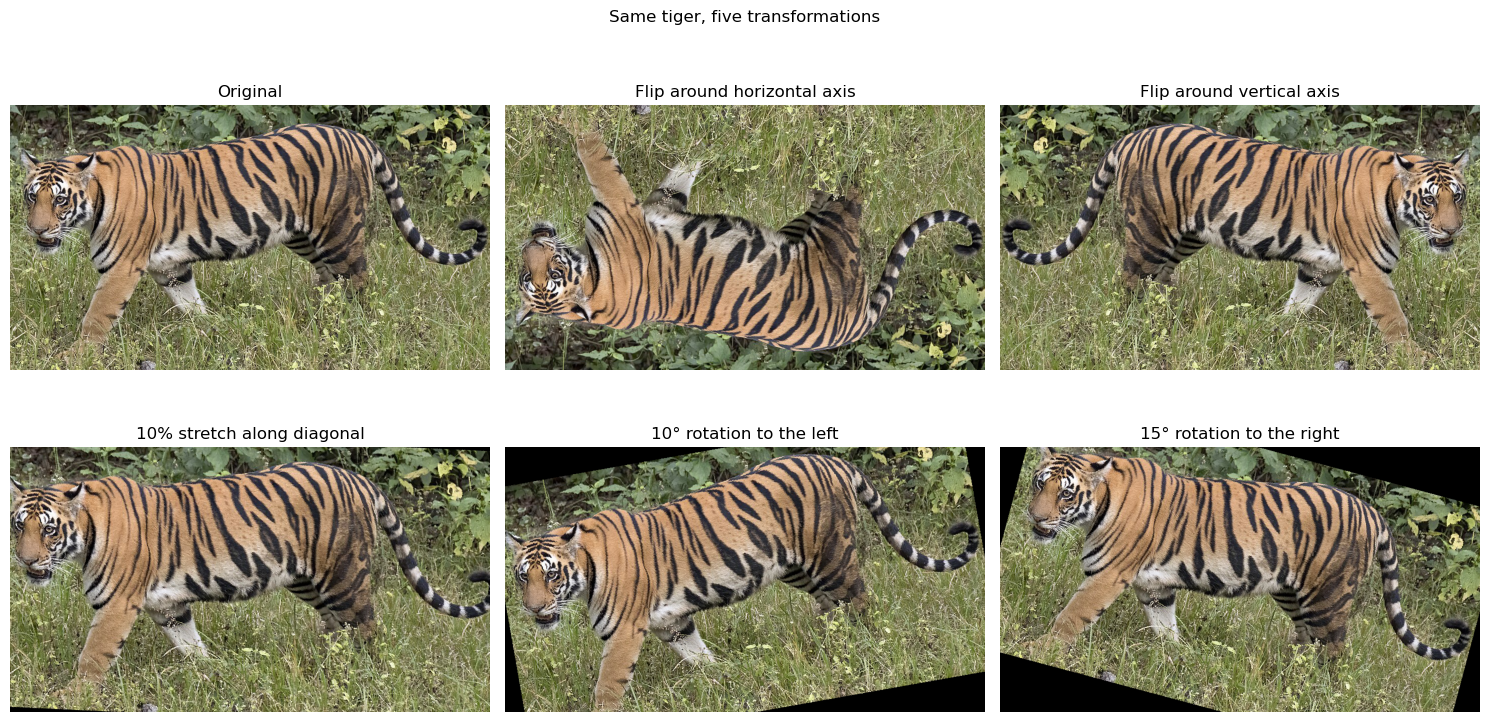

In [7]:
views = [                                               # List of (title, transformation) pairs to display.
    ('Original', image_transform),
    ('Flip around horizontal axis', flip_horizontal_axis),
    ('Flip around vertical axis', flip_vertical_axis),
    ('10% stretch along diagonal', diagonal_stretch),
    ('10° rotation to the left', rotate_left_10),
    ('15° rotation to the right', rotate_right_15),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))         # Grid of 2 rows x 3 columns = 6 image panels.

for axis, (title, transform) in zip(axes.flat, views):  # Pair each panel with one (title, transform).

    picture = transform(photo)                          # Apply the transformation; result is a [3, H, W] tensor. photo is the original tiger image, loaded in section 2.
    #So picture = transform(photo) means "apply this transformation to the tiger and call the result picture". When transform is flip_horizontal_axis, picture is the upside-down tiger.

    axis.imshow(picture.permute(1, 2, 0))               # Plotting uses height, width, channels, so reorder the axes.

    axis.set_title(title)                               # Label the panel.

    axis.axis('off')                                    # Hide the axis ticks and labels.

fig.suptitle('Same tiger, five transformations')        # Title for the whole figure.

plt.tight_layout()                                      # Reduce overlap between panels.

plt.show()                                              # Display the figure.

## Summary

- We downloaded a moderate-resolution tiger image.
- We used `transforms.Compose()` to build five transformation pipelines: two flips, a 10% diagonal stretch, a 10° left rotation, and a 15° right rotation.
- Each pipeline ends with `ToTensor()`, and the results are plotted next to the original image.